Rows: 100%|██████████| 512/512 [00:13<00:00, 38.48it/s]



χ² distorted        : 3,343,342
χ² distorted (full) : 181,615,526
χ² corrected        : 304,817
Shift RMS error : 1.79e-02 px
QE RMS error    : 0.29%


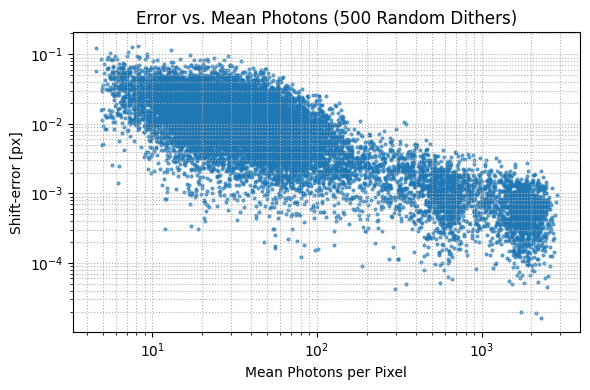

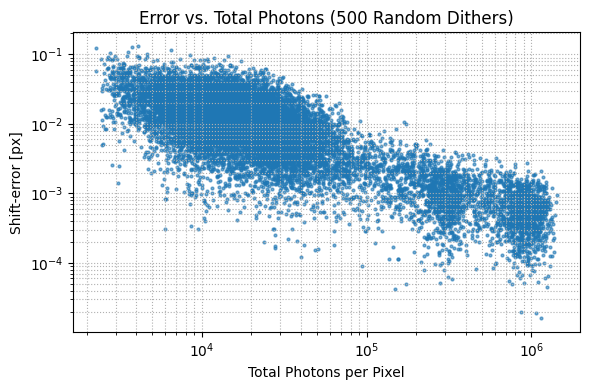

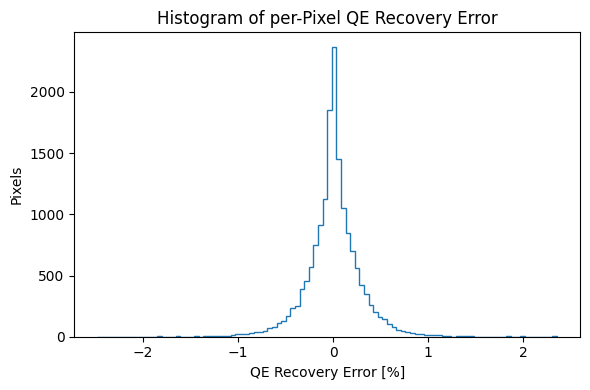

In [ ]:
# imports
import os, numpy as np, jax, jax.numpy as jnp
from jax import jacfwd, jit
from tqdm import trange
import dLuxToliman
from interpax import interp2d
import matplotlib.pyplot as plt
# user knobs
read_var   = 3.27**2        # read-noise variance
lam        = 1e-4           # ridge regulariser
n_dithers  = 500           # inclues (0,0)
dither_range = 1            # ± arcsec from origin
random_seed  = 42           # for reproducibility
# enable Jax 64-bit
os.environ["JAX_ENABLE_X64"] = "True"
jax.config.update("jax_enable_x64", True)

def warp(img, field_sup, order="cubic"):
    Hsup, Wsup = img.shape                        # oversampled PSF height / width
    ys, xs = jnp.arange(Hsup), jnp.arange(Wsup)   # 1D arrays which represent reference grid
    # for every (i,j), subtract the local dy shift and flatten
    coords_y = (ys[:, None] - field_sup[..., 1]).ravel()
    # for every (i,j), subtract the local dx shift and flatten
    coords_x = (xs[None, :] - field_sup[..., 0]).ravel()
    warped = interp2d(                       # sample img at sub-pixel coords
        coords_y, coords_x,                  # query points (row, col)
        xs, ys,                              # original grid vectors
        img,                                 # image to interpolate
        method=order,                        # "cubic" or "linear"
        extrap=True                          # allow constant extrapolation
    )
    # reshape back to 2D image
    return warped.reshape(Hsup, Wsup)

def downsample(arr, q):
    h, w = arr.shape # grab oversampled image dimensions
    return arr.reshape(h//q, q, w//q, q).mean((1, 3)) # return downsampled image


opt  = dLuxToliman.TolimanOpticalSystem(wf_npixels=256,
psf_npixels=128,
oversample=4) # generates the dLuxtoliman optic
ovsp        = opt.oversample # retrieves the oversampling factor
arcsec_det  = opt.psf_pixel_scale # retrives the PSF pixel scale
arcsec_sup  = arcsec_det / ovsp # retrives the oversampled pixel scale

def generate_dither_pattern(K, range_arcsec, seed=None):
    rng = np.random.default_rng(seed) # sets seed
    dith = [(0.0, 0.0)] # include origin as a dither position always
    for _ in range(K-1): # iterate up until K-1 as we subtract the origin from K
        dx = rng.uniform(-range_arcsec, range_arcsec) # generate random uniform number (dx) within ± range_arcsec
        dy = rng.uniform(-range_arcsec, range_arcsec) # generate random uniform number (dy) within ± rang_arcsec
        dith.append((dx, dy)) # store dither coordinate
    return np.array(dith) # return all dither coordinates

dith_arc = generate_dither_pattern(n_dithers, dither_range, random_seed) # generate dithers
K        = len(dith_arc) # store amount of dithers as K


def psf_xy(t):
    dx, dy = t                                   # unpack the 2-element vector

    # build alpha cen source
    src = dLuxToliman.sources.AlphaCen(          # synthetic binary star
        n_wavels      = 5,                       # 5 wavelength samples
        separation    = 10.,                     # arcsec binary separation
        position_angle= 90.,                     # position angle  of secondary
        x_position    = dx,                      # field offset in x
        y_position    = dy                       # field offset in y
    )

    # pass source through the Toliman telescope model
    tel = dLuxToliman.telescopes.Toliman(opt, src)

    # produce oersampled PSF model and force 64-bit for Jax
    return tel.model().astype(jnp.float64)

# JIT-compile the PSF generator for speed
psf_jit = jit(psf_xy)

# JIT-compile the Jacobian of psf_xy w.r.t. (dx,dy) to get dI/dx and dI/dy
grad_jit = jit(jacfwd(psf_xy, holomorphic=False))

rng = np.random.default_rng(0)                       # reproducible RNG
shift_det = rng.uniform(-0.01, 0.01, (128,128,2))    # dx,dy in detector px
delta_rho_det = -rng.normal(0.025, 0.025, (128,128)) # approx -2.5 percent ± 2.5 percent QE
rho_det       = 1.0 + delta_rho_det                  # per-pixel gain map
# upscale shift field to the supersampled grid (4× in each axis)
field_sup_base = np.kron(shift_det * ovsp,
                         np.ones((ovsp,ovsp,1)))
# upscale QE map likewise (tile each detector gain into 4×4 block)
rho_sup2d_base = np.kron(rho_det,
                         np.ones((ovsp,ovsp)))  
# compute reference chi² (not the same chi² we minimise in the algorithm, this is just a measure of error (distorted vs ideal at origin))
psf0_sup  = np.asarray(psf_jit(jnp.array([0.,0.])))    # ideal PSF at centre
dist0_sup = warp(psf0_sup, field_sup_base)             # apply true shifts
chi2_dist0 = np.sum((psf0_sup - dist0_sup)**2)         # baseline mismatch (without QE)
dist0_sup_qe = dist0_sup * rho_sup2d_base              # apply QE
chi2_dist0_full = np.sum((psf0_sup - dist0_sup_qe)**2) # full baseline mismatch (with QE)

ideal, gx, gy = [], [], []                     # lists will hold K arrays
for dx_k, dy_k in dith_arc:                    # loop over K (dx,dy) offsets
    # ideal oversampled PSF at that offset
    I_sup = np.asarray(psf_jit(jnp.array([dx_k, dy_k])))
    # analytic gradients dI/dx and dI/dy (third axis→0:x, 1:y)
    G_sup = np.asarray(grad_jit(jnp.array([dx_k, dy_k])))
    # append to lists
    ideal.append(I_sup)            
    gx.append(G_sup[..., 0])       # channel 0 → d/dx
    gy.append(G_sup[..., 1])       # channel 1 → d/dy

# convert lists to stacks
ideal = np.stack(ideal)            # ideal PSF 'cube'
gx    = np.stack(gx)               # gradient wrt x
gy    = np.stack(gy)               # gradient wrt y

dist_sup_stack = np.stack([warp(im, field_sup_base) for im in ideal]) # warp each ideal PSF
qe_stack       = dist_sup_stack * rho_sup2d_base                      # apply gain to each warped PSF

# construct the variance stack as the sum of shot noise and read noise
var_stack = qe_stack + read_var

meas = []                                          # list will hold K noisy arrays
for k in range(K):                                 # loop over every dither frame
    var_sup  = var_stack[k]                        # obtain the variance for current frame
    # draw Gaussian noise with std = square root of the variance, same shape as one frame
    meas_sup = qe_stack[k] + rng.normal(scale = np.sqrt(var_sup), size  = var_sup.shape)
    meas.append(meas_sup)                          # store noisy frame

meas = np.stack(meas)                              # convert list to stack

# compute residuals (measured - ideal)
R = meas - ideal   

# preparing for per-pixel 3-parameter least-squares
Hsup, Wsup = ideal.shape[1:]            # supersampled image size (512 × 512)
# output maps initialised to zero
dx_sup = np.zeros((Hsup, Wsup))         # estimated Δx  (super-px)
dy_sup = np.zeros_like(dx_sup)          # estimated Δy
dr_sup = np.zeros_like(dx_sup)          # estimated Δρ  (fractional QE)

# per-pixel 3-parameter least-squares - loop over each pixel in the supersampled grid
for i in trange(Hsup, desc="Rows"):
    for j in range(Wsup):
        # construct G for specific pixel (i,j)
        #  column 0 :  −dI/dx   (negative sign matches Taylor expansion)
        #  column 1 :  −dI/dy
        #  column 2 :   I       
        G = np.stack([-gx[:, i, j],         
                      -gy[:, i, j],
                       ideal[:, i, j]], axis=1)  

        # grab specific residuals for this pixel
        r = R[:, i, j]

        # pixel-wise weights  w_k = 1/σ_k²  (inverse variance)
        w = 1.0 / var_stack[:, i, j]

        # multiply each row of G and each entry of r by square root of the weight
        # we multiply by sqrt(w) to avoid numerical issues with small weights and for computational stability
        sqrtw = np.sqrt(w)                    # shape (K,)
        Gw = G * sqrtw[:, None]               # broadcasting → (K,3)
        rw = r * sqrtw                        # shape (K,)

        # weighted normal equations with ridge
        A = Gw.T @ Gw + lam * np.eye(3)       # shape (3,3)
        b = Gw.T @ rw                         # shape (3,)

        # solve for [Δx, Δy, Δρ] at this (i,j)
        dx_sup[i, j], dy_sup[i, j], dr_sup[i, j] = np.linalg.solve(A, b)


# ---------- diagnostics --------------------------------------------------
# build recovered supersampled shift field ⟨Δx̂ , Δŷ⟩  (arc-sec / super-px)
est_sup = np.stack([
        -dx_sup / arcsec_sup,     # Δx̂ (super-px) → arc-sec
        -dy_sup / arcsec_sup      # Δŷ (super-px) → arc-sec
    ], axis=-1)

# undo warp on the FIRST distorted frame using recovered field
undist = warp(dist_sup_stack[0], -est_sup)          # back-shift image
chi2_corr = np.sum((ideal[0] - undist) ** 2)        # χ² after correction

print(f"\nχ² distorted        : {chi2_dist0:,.0f}")
print(f"χ² distorted (full) : {chi2_dist0_full:,.0f}")
print(f"χ² corrected        : {chi2_corr:,.0f}")

# detector-grid comparison using downsample function
# ground-truth detector-pixel shifts   (average every 4×4 block then /ovsp)
field_det = np.stack([
        downsample(field_sup_base[..., 0], ovsp) / ovsp,   # true Δx_det
        downsample(field_sup_base[..., 1], ovsp) / ovsp    # true Δy_det
    ], axis=-1)

# now do the same downsampling for recovered shifts
est_shift_det = np.stack([
        -downsample(dx_sup, ovsp) / arcsec_det,            # est Δx_det
        -downsample(dy_sup, ovsp) / arcsec_det             # est Δy_det
    ], axis=-1)

# extract the recovered shifts from the detector grid (use these later for plotting)
dx_det = est_shift_det[..., 0]      #  recovered Δx_det
dy_det = est_shift_det[..., 1]      #  recovered Δy_det

# compute per-pixel errors on the detector grid
err_x   = est_shift_det[..., 0] - field_det[..., 0]        # x-error
err_y   = est_shift_det[..., 1] - field_det[..., 1]        # y-error
err_mag = np.sqrt(err_x**2 + err_y**2)                     # magnitude error

# QE (gain) recovery error on detector grid
dr_det      = downsample(dr_sup, ovsp)                     # avg 4×4 blocks
rho_est_det = 1.0 + dr_det                                 # recovered gain
qe_err_rms  = np.std(rho_est_det - rho_det)                # RMS QE error

print(f"Shift RMS error : {np.sqrt(np.mean(err_mag**2)):.2e} px")
print(f"QE RMS error    : {qe_err_rms:.2%}")

# photon counts
sum_phot = np.zeros((128, 128))             # initialise running total of detected photons per pixel
for k in range(K):                          # loop over all dithered frames
    sum_phot += downsample(meas[k], ovsp)   # add counts from frame k
mean_phot  = sum_phot / K                   # <N>  = average photons / frame 
total_phot = sum_phot                       # N_tot = photons accumulated over K frames
mask       = total_phot > 0                 # boolean mask: ignore pixels that never saw light

In [ ]:
# preliminary plots
plt.figure(figsize=(6,4))
plt.scatter(mean_phot[mask], err_mag[mask], s=4, alpha=0.6)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Mean Photons per Pixel")
plt.ylabel("Shift-error [px]")
plt.title(f"Error vs. Mean Photons ({K} Random Dithers)")
plt.grid(True, which="both", ls=":")
plt.tight_layout()
plt.savefig("error_vs_mean_photons.pdf")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(total_phot[mask], err_mag[mask], s=4, alpha=0.6)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Total Photons per Pixel")
plt.ylabel("Shift-error [px]")
plt.title(f"Error vs. Total Photons ({K} Random Dithers)")
plt.grid(True, which="both", ls=":")
plt.tight_layout()
plt.savefig("error_vs_total_photons.pdf")
plt.show()

plt.figure(figsize=(6,4))
plt.hist((rho_est_det - rho_det).ravel()*100, bins=100, histtype='step')
plt.xlabel("QE Recovery Error [%]"); plt.ylabel("Pixels")
plt.title("Histogram of per-Pixel QE Recovery Error")
plt.tight_layout()
plt.savefig("qe_recovery_error_histogram.pdf")
plt.show()

K=500 LS: 100%|██████████| 512/512 [00:28<00:00, 17.94it/s]


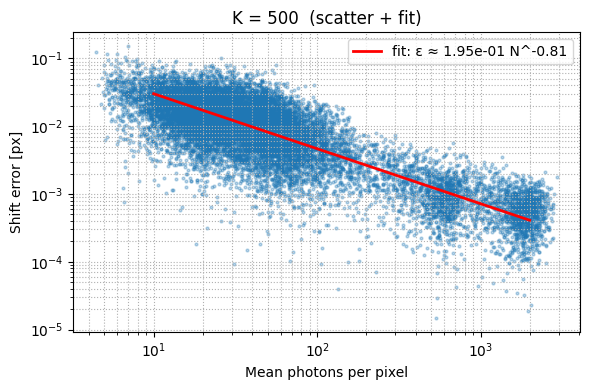

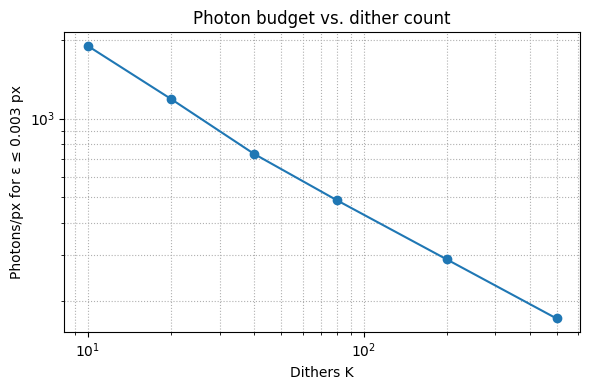


Target ε = 0.003 px

   K   |    A (prefactor)   |   b (slope)   |  N_phot req
-------+--------------------+---------------+-------------
   10 |    1.964e+00     |  -0.859      |    1.9e+03
   20 |    1.214e+00     |  -0.848      |   1.19e+03
   40 |    8.519e-01     |  -0.856      |        734
   80 |    5.635e-01     |  -0.846      |        487
  200 |    3.374e-01     |  -0.833      |        289
  500 |    1.952e-01     |  -0.811      |        172


In [ ]:
# fits a line in log-log space to the error vs. mean photons plot and estimates the average number of photons required to achive the error
# target, as a function of the number of dithers
# ── imports ──────────────────────────────────────────────────────────
import os, numpy as np, jax, jax.numpy as jnp, matplotlib.pyplot as plt
from jax import jacfwd, jit
from tqdm import trange
import dLuxToliman
from interpax import interp2d

# ── JAX 64-bit ───────────────────────────────────────────────────────
os.environ["JAX_ENABLE_X64"] = "True"
jax.config.update("jax_enable_x64", True)

# ── user knobs ───────────────────────────────────────────────────────
dither_list   = [10, 20, 40, 80, 200, 500]
target_eps    = 0.003                         # desired shift accuracy [px]
read_var      = 3.27**2                       # read-noise variance
lam           = 1e-4                          # LS regulariser
rng_seed_sim  = 0                             # dithers + noise
rng_seed_truth= 1                             # ground-truth maps
# --------------------------------------------------------------------

# ── helper functions ────────────────────────────────────────────────
def warp(img, field_sup, order="cubic"):
    Hsup, Wsup = img.shape
    ys, xs = jnp.arange(Hsup), jnp.arange(Wsup)
    coords_y = (ys[:, None] - field_sup[..., 1]).ravel()
    coords_x = (xs[None, :] - field_sup[..., 0]).ravel()
    return interp2d(coords_y, coords_x, xs, ys, img,
                    method=order, extrap=True).reshape(Hsup, Wsup)

def downsample(arr, q):                       # 512→128
    h, w = arr.shape
    return arr.reshape(h//q, q, w//q, q).mean((1, 3))

# ── optics (built once) ─────────────────────────────────────────────
opt  = dLuxToliman.TolimanOpticalSystem(wf_npixels=256,
                                        psf_npixels=128,
                                        oversample=4)
ovsp        = opt.oversample
arcsec_det  = opt.psf_pixel_scale
arcsec_sup  = arcsec_det / ovsp

@jit
def psf_xy(t):
    dx, dy = t
    src = dLuxToliman.sources.AlphaCen(
        n_wavels=5, separation=10., position_angle=90.,
        x_position=dx, y_position=dy)
    return dLuxToliman.telescopes.Toliman(opt, src).model().astype(jnp.float64)

psf_jit  = psf_xy
grad_jit = jit(jacfwd(psf_xy, holomorphic=False))

# ── deterministic master dither list ────────────────────────────────
max_K        = max(dither_list)
rng_dith     = np.random.default_rng(rng_seed_sim)
dither_master= np.vstack([[0.,0.],
                          rng_dith.uniform(-1,1,size=(max_K-1,2))])

# ── storage for outputs ─────────────────────────────────────────────
fit_params  = {}           # {K: (a,b)}
required_N  = []           # photons needed for target_eps
scatter_dat = {}           # store data for largest-K plot

# ===================================================================
#  MAIN LOOP OVER dither counts
# ===================================================================
for K in dither_list:
    dith = dither_master[:K]

    # --- ground-truth maps (same every K) ---------------------------
    rng_truth = np.random.default_rng(rng_seed_truth)
    shift_det = rng_truth.uniform(-0.01,0.01,(128,128,2))
    loss      = np.clip(rng_truth.normal(0.025,0.0125,(128,128)),0.0,0.05)
    rho_det   = 1.0 - loss
    field_sup = np.kron(shift_det*ovsp, np.ones((ovsp,ovsp,1)))
    rho_sup   = np.kron(rho_det,        np.ones((ovsp,ovsp)))

    # --- PSFs & gradients ------------------------------------------
    ideal_sup, gx_sup, gy_sup = [], [], []
    for k in trange(K, desc=f"K={K} PSF+grad"):
        I_sup = np.asarray(psf_jit(jnp.array(dith[k])))
        G_sup = np.asarray(grad_jit(jnp.array(dith[k])))
        ideal_sup.append(I_sup)
        gx_sup.append(G_sup[...,0]); gy_sup.append(G_sup[...,1])
    ideal_sup = np.stack(ideal_sup); gx_sup = np.stack(gx_sup); gy_sup = np.stack(gy_sup)

    # --- forward model + noise -------------------------------------
    dist_sup = np.stack([warp(im, field_sup) for im in ideal_sup])
    qe_sup   = dist_sup * rho_sup
    var_sup  = qe_sup + read_var
    rng_noise= np.random.default_rng(rng_seed_sim+K)
    meas_sup = qe_sup + rng_noise.normal(scale=np.sqrt(var_sup), size=var_sup.shape)
    R_sup    = meas_sup - ideal_sup

    # --- weighted LS (progress bar) --------------------------------
    Hsup,Wsup = ideal_sup.shape[1:]
    dx_sup = np.zeros((Hsup,Wsup)); dy_sup = np.zeros_like(dx_sup)
    for i in trange(Hsup, desc=f"K={K} LS"):
        for j in range(Wsup):
            G = np.stack([-gx_sup[:,i,j], -gy_sup[:,i,j], ideal_sup[:,i,j]], axis=1)
            r = R_sup[:,i,j]
            w = 1.0 / np.maximum(var_sup[:,i,j], 1e-12)
            sw= np.sqrt(w)
            A = (G*sw[:,None]).T @ (G*sw[:,None]) + lam*np.eye(3)
            b = (G*sw[:,None]).T @ (r*sw)
            dx_sup[i,j], dy_sup[i,j], _ = np.linalg.solve(A,b)

    # --- detector-scale errors -------------------------------------
    dx_det = (-dx_sup.reshape(128,ovsp,128,ovsp).mean((1,3)))/arcsec_det
    dy_det = (-dy_sup.reshape(128,ovsp,128,ovsp).mean((1,3)))/arcsec_det
    err_mag= np.sqrt((dx_det-shift_det[...,0])**2 +
                     (dy_det-shift_det[...,1])**2)

    # --- photon statistics -----------------------------------------
    sum_phot = np.zeros((128,128))
    for k in range(K):
        sum_phot += downsample(meas_sup[k], ovsp)
    mean_phot = sum_phot / K

    # --- log–log fit (photon-noise regime) -------------------------
    #mask = (mean_phot > 20) & (mean_phot < 500)
    mask = (mean_phot > 20)
    x = np.log10(mean_phot[mask].ravel())
    y = np.log10(err_mag  [mask].ravel())
    slope, intercept = np.polyfit(x, y, 1)    # slope=b, intercept=a
    b = slope;  a = intercept
    fit_params[K] = (a,b)

    if b < 0:                                 # meaningful fit
        Nreq = (target_eps / 10**a)**(1/b)
    else:                                     # slope ≥ 0 → ignore
        Nreq = np.nan
    required_N.append(Nreq)

    if K == max_K:
        scatter_dat.update(dict(mean_phot=mean_phot,
                                err_mag=err_mag, a=a, b=b))

# ===================================================================
#  PLOTS
# ===================================================================
# -- scatter + fit for largest K ------------------------------------
mp   = scatter_dat['mean_phot'].ravel()
eps  = scatter_dat['err_mag'].ravel()
a,b  = scatter_dat['a'], scatter_dat['b']

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(mp, eps, s=4, alpha=0.3)
N_line = np.logspace(1, 3.3, 200)
ax.plot(N_line, 10**a * N_line**b, 'r-', lw=2,
        label=f'fit: ε ≈ {10**a:.2e} N^{b:.2f}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Mean photons per pixel'); ax.set_ylabel('Shift error [px]')
ax.set_title(f'K = {max_K}  (scatter + fit)')
ax.grid(True, which='both', ls=':')
ax.legend()
plt.tight_layout()
plt.savefig("scatter_fit_largest_K.pdf")
plt.show()

# -- photon budget vs dither count ----------------------------------
plt.figure(figsize=(6,4))
plt.plot(dither_list, required_N, 'o-')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Dithers K'); plt.ylabel(f'Photons/px for ε ≤ {target_eps} px')
plt.title('Photon budget vs. dither count')
plt.grid(True, which='both', ls=':'); plt.tight_layout()
plt.savefig("photon_budget_vs_dither_count.pdf")
plt.show()

# ===================================================================
#  CONSOLE SUMMARY
# ===================================================================
print(f"\nTarget ε = {target_eps} px\n")
print("   K   |    A (prefactor)   |   b (slope)   |  N_phot req")
print("-------+--------------------+---------------+-------------")
for K,N in zip(dither_list, required_N):
    a,b = fit_params[K]
    print(f"{K:5d} | {10**a:12.3e}     | {b:7.3f}      | {N:>10.3g}")



K=500  LS: 100%|██████████| 512/512 [00:24<00:00, 21.32it/s]


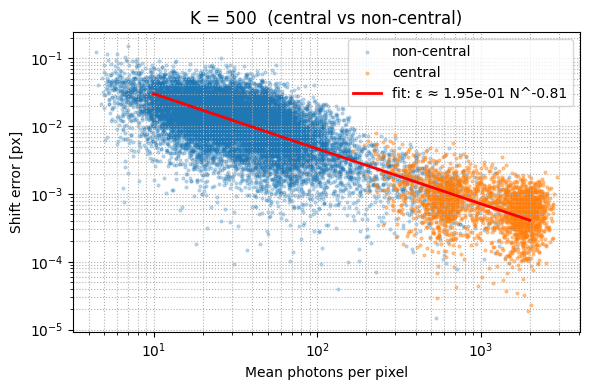

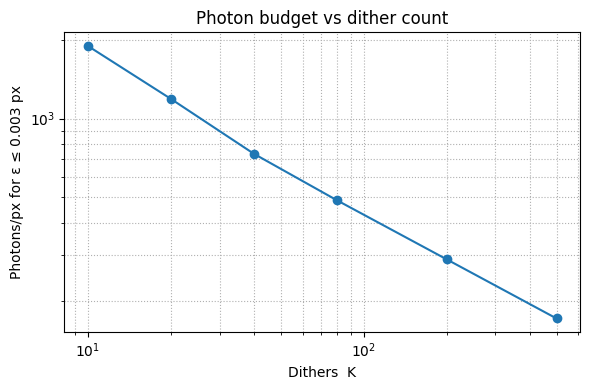

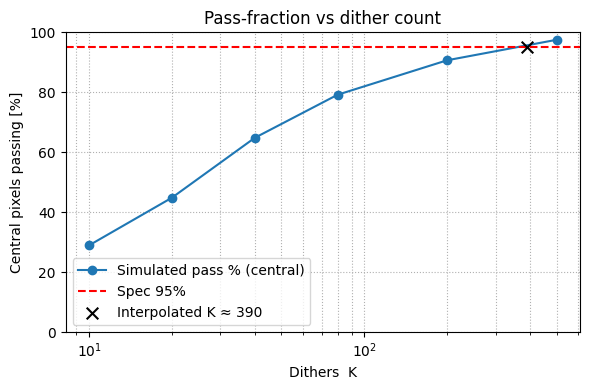


Spec: ε ≤ 0.003 px; need 95% of central pixels to pass.

   K | pass% central
----+----------------
  10|     28.94%
  20|     44.83%
  40|     64.80%
  80|     79.18%
 200|     90.68%
 500|     97.51%

>>> Approx. K required to meet spec by interpolation: K ≈ 390


In [ ]:
# plots PSF centroid pixels in a different colour (defined by central_thr), and fits a line to the curve (in log-log space)
# it then apprpximately finds the required K to achieve central_frac_req fraction of pixels within the central_thr threshold
# (still also plots photon budget vs dither count)
# ───────────────────────── imports ───────────────────────────
import os, numpy as np, jax, jax.numpy as jnp, matplotlib.pyplot as plt
from jax import jacfwd, jit
from tqdm import trange
import dLuxToliman
from interpax import interp2d

# ───────────────── JAX 64-bit ────────────────────────────────
os.environ["JAX_ENABLE_X64"] = "True"
jax.config.update("jax_enable_x64", True)

# ───────────────── user knobs ────────────────────────────────
dither_list       = [10, 20, 40, 80, 200, 500]
eps_target        = 0.003          # shift-error spec [px]  (magnitude)
central_thr       = 0.04           # 3 % of peak defines “central”
central_frac_req  = 0.95           # e.g. 0.95 → 95 % must pass
read_var          = 3.27**2
lam               = 1e-4
rng_seed_sim      = 0
rng_seed_truth    = 1
# ------------------------------------------------------------

# ─────────── helpers (unchanged) ─────────────────────────────
def warp(img, field_sup, order="cubic"):
    Hsup,Wsup = img.shape
    ys,xs = jnp.arange(Hsup), jnp.arange(Wsup)
    cy = (ys[:,None]-field_sup[...,1]).ravel()
    cx = (xs[None,:]-field_sup[...,0]).ravel()
    return interp2d(cy, cx, xs, ys, img,
                    method=order, extrap=True).reshape(Hsup,Wsup)

def downsample(arr, q):            # 512→128
    h,w = arr.shape
    return arr.reshape(h//q,q,w//q,q).mean((1,3))

# ─────────── optics object (unchanged) ───────────────────────
opt = dLuxToliman.TolimanOpticalSystem(wf_npixels=256,
                                       psf_npixels=128,
                                       oversample=4)
ovsp        = opt.oversample
arcsec_det  = opt.psf_pixel_scale
arcsec_sup  = arcsec_det / ovsp

@jit
def psf_xy(t):
    dx,dy = t
    src = dLuxToliman.sources.AlphaCen(n_wavels=5, separation=10.,
                                       position_angle=90.,
                                       x_position=dx, y_position=dy)
    return dLuxToliman.telescopes.Toliman(opt, src).model().astype(jnp.float64)

psf_jit  = psf_xy
grad_jit = jit(jacfwd(psf_xy, holomorphic=False))   # ∂I/∂dither

# master dither list (deterministic) -------------------------
max_K        = max(dither_list)
rng_dith     = np.random.default_rng(rng_seed_sim)
dither_master= np.vstack([[0.,0.],
                          rng_dith.uniform(-1,1,size=(max_K-1,2))])

# storage -----------------------------------------------------
fit_params    = {}    # {K:(a,b)}
required_N    = []    # photons needed for eps_target
central_pass  = []    # pass-fraction per K
first_K_ok    = None  # first K that meets spec
scatter_dat   = {}    # for biggest-K scatter plot

# =================================================================
#  MAIN LOOP  (algorithm unchanged)
# =================================================================
for K in dither_list:
    dith = dither_master[:K]

    # ground-truth detector maps (same every K)
    rng_truth = np.random.default_rng(rng_seed_truth)
    shift_det = rng_truth.uniform(-0.01,0.01,(128,128,2))
    loss      = np.clip(rng_truth.normal(0.025,0.0125,(128,128)),0,0.05)
    rho_det   = 1.0 - loss
    field_sup = np.kron(shift_det*ovsp, np.ones((ovsp,ovsp,1)))
    rho_sup   = np.kron(rho_det,        np.ones((ovsp,ovsp)))

    # PSFs & raw ∂I/∂dither
    ideal_sup, gx_sup, gy_sup = [], [], []
    for k in trange(K, desc=f"K={K}  PSF+grad"):
        I_sup = np.asarray(psf_jit(jnp.array(dith[k])))
        G_sup = np.asarray(grad_jit(jnp.array(dith[k])))
        ideal_sup.append(I_sup)
        gx_sup.append(G_sup[...,0]); gy_sup.append(G_sup[...,1])
    ideal_sup = np.stack(ideal_sup)
    gx_sup    = np.stack(gx_sup)
    gy_sup    = np.stack(gy_sup)

    # central mask
    psf0_det     = downsample(ideal_sup[0], ovsp)
    central_mask = psf0_det >= central_thr * psf0_det.max()

    # forward model + noise
    dist_sup = np.stack([warp(im, field_sup) for im in ideal_sup])
    qe_sup   = dist_sup * rho_sup
    var_sup  = qe_sup + read_var
    meas_sup = qe_sup + np.random.default_rng(rng_seed_sim+K)\
                        .normal(scale=np.sqrt(var_sup), size=var_sup.shape)
    R_sup    = meas_sup - ideal_sup

    # LS solve
    Hsup,Wsup = ideal_sup.shape[1:]
    dx_sup = np.zeros((Hsup,Wsup)); dy_sup = np.zeros_like(dx_sup)
    for i in trange(Hsup, desc=f"K={K}  LS"):
        for j in range(Wsup):
            G = np.stack([-gx_sup[:,i,j], -gy_sup[:,i,j], ideal_sup[:,i,j]],
                         axis=1)
            r = R_sup[:,i,j]
            w = 1.0 / np.maximum(var_sup[:,i,j],1e-12)
            sw= np.sqrt(w)
            A = (G*sw[:,None]).T @ (G*sw[:,None]) + lam*np.eye(3)
            b = (G*sw[:,None]).T @ (r*sw)
            dx_sup[i,j], dy_sup[i,j], _ = np.linalg.solve(A,b)

    # detector-grid errors
    dx_det = (-dx_sup.reshape(128,ovsp,128,ovsp).mean((1,3)))/arcsec_det
    dy_det = (-dy_sup.reshape(128,ovsp,128,ovsp).mean((1,3)))/arcsec_det
    err_mag= np.sqrt((dx_det-shift_det[...,0])**2 +
                     (dy_det-shift_det[...,1])**2)

    # central-pixel pass fraction
    pass_frac = (err_mag <= eps_target)[central_mask].mean()
    central_pass.append(pass_frac)
    if first_K_ok is None and pass_frac >= central_frac_req:
        first_K_ok = K

    # photon statistics → diagnostics only
    sum_phot = np.zeros((128,128))
    for k in range(K):
        sum_phot += downsample(meas_sup[k], ovsp)
    mean_phot = sum_phot / K
    mask = mean_phot > 20
    b,a = np.polyfit(np.log10(mean_phot[mask].ravel()),
                     np.log10(err_mag  [mask].ravel()),1)
    fit_params[K] = (a,b)
    Nreq = (eps_target/10**a)**(1/b) if b < 0 else np.nan
    required_N.append(Nreq)

    if K == dither_list[-1]:
        scatter_dat = dict(mean_phot=mean_phot, err_mag=err_mag,
                           central_mask=central_mask, a=a, b=b, K=K)

# =================================================================
# 1.  scatter plot (largest K)  — unchanged
# =================================================================
mp   = scatter_dat['mean_phot'].ravel()
eps  = scatter_dat['err_mag'].ravel()
cmas = scatter_dat['central_mask'].ravel()
a,b  = scatter_dat['a'], scatter_dat['b'];  Kmax = scatter_dat['K']

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(mp[~cmas], eps[~cmas], s=4, alpha=0.25, label='non-central')
ax.scatter(mp[cmas],  eps[cmas],  s=4, alpha=0.4,
           color='tab:orange', label='central')
N_line = np.logspace(1,3.3,200)
ax.plot(N_line, 10**a * N_line**b, 'r-', lw=2,
        label=f'fit: ε ≈ {10**a:.2e} N^{b:.2f}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Mean photons per pixel'); ax.set_ylabel('Shift error [px]')
ax.set_title(f'K = {Kmax}  (central vs non-central)')
ax.grid(True, which='both', ls=':'); ax.legend()
plt.tight_layout()
plt.savefig("scatter_fit_largest_K_with_centre_coloured.pdf")
plt.show()

# =================================================================
# 2. photon-budget plot  — unchanged
# =================================================================
plt.figure(figsize=(6,4))
plt.plot(dither_list, required_N, 'o-')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Dithers  K')
plt.ylabel(f'Photons/px for ε ≤ {eps_target} px')
plt.title('Photon budget vs dither count')
plt.grid(True, which='both', ls=':'); plt.tight_layout()
#plt.savefig("photon_budget_vs_dither_count.pdf")
plt.show()

# =================================================================
# 3. NEW: Pass-fraction vs K plot with spec line & marker
# =================================================================
K_arr   = np.array(dither_list, dtype=float)
pass_arr= np.array(central_pass)

plt.figure(figsize=(6,4))
plt.plot(K_arr, pass_arr*100, 'o-', label='Simulated pass % (central)')
plt.axhline(central_frac_req*100, color='r', ls='--',
            label=f'Spec {central_frac_req*100:.0f}%')

# --- find/mark intersection by linear interpolation --------------
K_mark = None
for i in range(len(K_arr)-1):
    if pass_arr[i] < central_frac_req <= pass_arr[i+1]:
        # linear interp in K space
        f0, f1 = pass_arr[i], pass_arr[i+1]
        K0, K1 = K_arr[i], K_arr[i+1]
        K_mark = K0 + (central_frac_req - f0)*(K1-K0)/(f1-f0)
        plt.scatter(K_mark, central_frac_req*100,
                    color='k', zorder=5, marker='x', s=70,
                    label=f'Interpolated K ≈ {K_mark:.0f}')
        break
if K_mark is None and pass_arr[0] >= central_frac_req:
    K_mark = K_arr[0]
    plt.scatter(K_mark, central_frac_req*100,
                color='k', zorder=5, marker='x', s=70,
                label=f'K ≈ {K_mark:.0f} (already pass)')

plt.xscale('log'); plt.ylim(0,100)
plt.xlabel('Dithers  K'); plt.ylabel('Central pixels passing [%]')
plt.title('Pass-fraction vs dither count')
plt.grid(True, which='both', ls=':'); plt.legend(); plt.tight_layout()
plt.savefig("pass_fraction_vs_dither_count.pdf")
plt.show()

# =================================================================
# 4. Console summary
# =================================================================
print(f"\nSpec: ε ≤ {eps_target} px; "
      f"need {central_frac_req*100:.0f}% of central pixels to pass.\n")
print("   K | pass% central")
print("----+----------------")
for K, frac in zip(K_arr, pass_arr):
    print(f"{K:4.0f}| {frac*100:9.2f}%")

if K_mark is not None:
    print(f"\n>>> Approx. K required to meet spec by interpolation: "
          f"K ≈ {K_mark:.0f}")
elif first_K_ok:
    print(f"\n>>> First K meeting spec exactly: K = {first_K_ok}")
else:
    print("\n>>> Spec not met within tested K range")


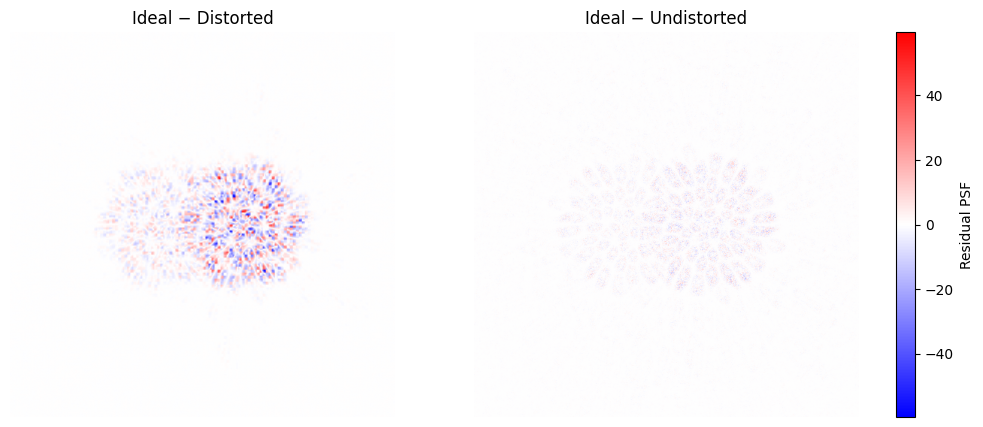

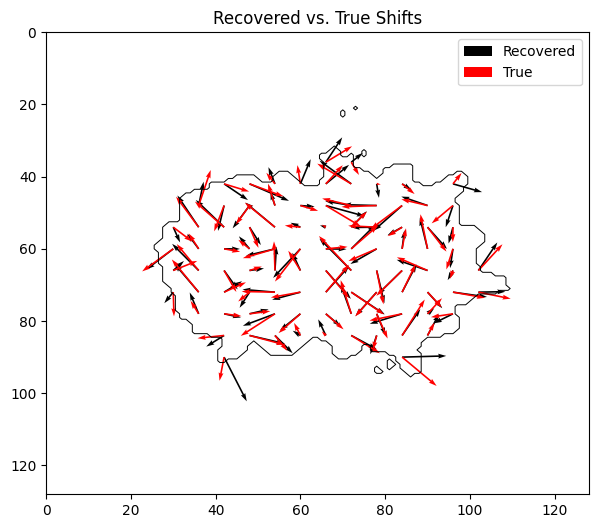

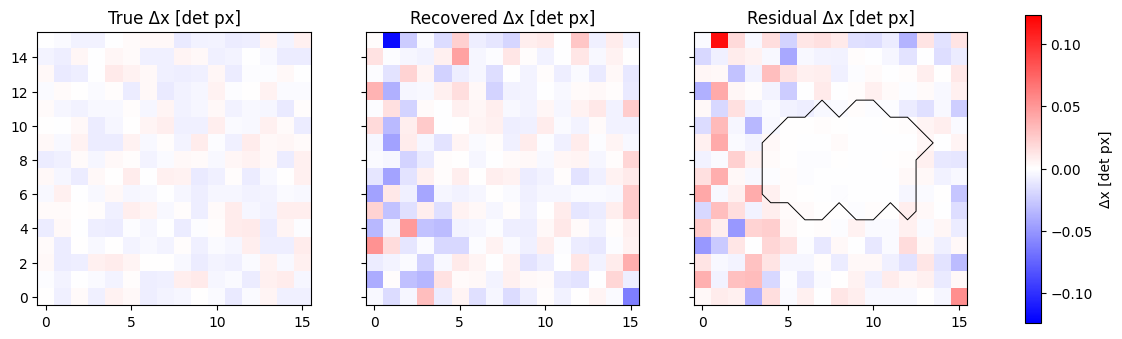

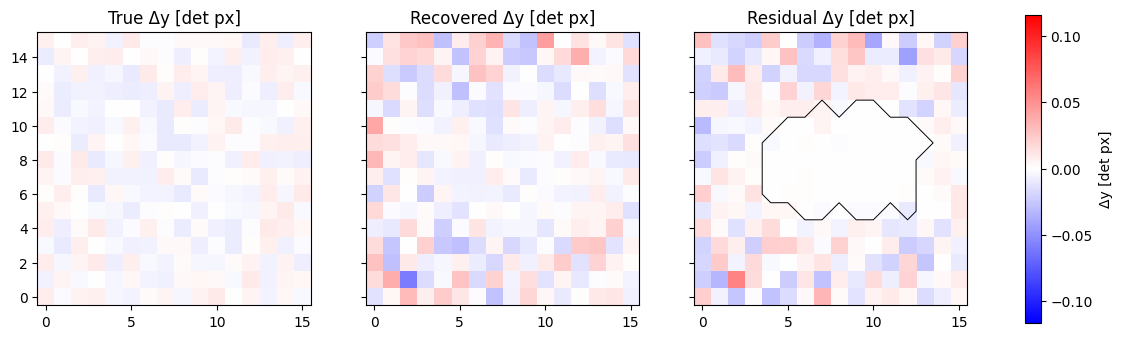

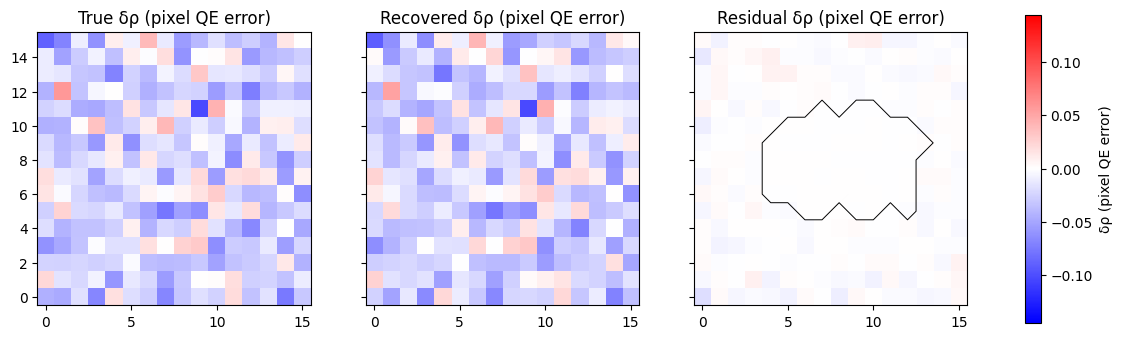

‖Ideal − Distorted‖₂  = 1.83e+03
‖Ideal − Undistorted‖₂= 5.52e+02


In [ ]:
# ---------------------------------------------------------------
#  BIG PLOTTING STUFF
# ---------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# ─── 0)  MASKS + GLOBAL SETTINGS ────────────────────────────────
PLOT_FRAC_QUIV = 0.04    # keep quiver arrows inside brightest 3 %
PLOT_FRAC_HM   = 0       # 0 → show entire heat-map
CONTOUR_FRAC   = 0.04    # outline PSF footprint at 3 % peak
SHOW_CONTOUR   = True
QUIVER_STEP    = 6       # sample every 6 px
HEAT_SUBSAMPLE = 8       # stride in heat-maps
QUIVER_SCALE   = 0.15    # arrow scale

# Detector-scale stack of ideal PSFs (128×128)
ideal_det = np.stack([downsample(im, ovsp) for im in ideal])   # (K,128,128)
mean_psf  = ideal_det.mean(axis=0)
peak      = mean_psf.max()

mask_plot_QUIV = (mean_psf > PLOT_FRAC_QUIV * peak) if PLOT_FRAC_QUIV else np.ones_like(mean_psf, bool)
mask_plot_HM   = (mean_psf > PLOT_FRAC_HM   * peak) if PLOT_FRAC_HM   else np.ones_like(mean_psf, bool)
mask_contour   = (mean_psf > CONTOUR_FRAC * peak) if CONTOUR_FRAC else np.ones_like(mean_psf, bool)

def add_outline(ax, mask, full_shape):
    """Draw rectangle or contour around PSF footprint."""
    if not SHOW_CONTOUR: return
    if mask.all():
        H, W = full_shape
        ax.add_patch(plt.Rectangle((0, 0), W, H, fill=False, lw=0.7, ec='k'))
    else:
        ax.contour(mask, levels=[0.5], colors='k', linewidths=0.7)

# ─── 1)  PSF RESIDUAL IMAGES  (512×512) ─────────────────────────
res_dist   = psf0_sup - dist0_sup
res_undist = psf0_sup - undist

vmax_res = np.max(np.abs([res_dist, res_undist]))
norm_res = TwoSlopeNorm(vmin=-vmax_res, vcenter=0.0, vmax=+vmax_res)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
im0 = axes[0].imshow(res_dist,   origin='lower', cmap='bwr', norm=norm_res)
axes[0].set_title("Ideal − Distorted");  axes[0].axis('off')
im1 = axes[1].imshow(res_undist, origin='lower', cmap='bwr', norm=norm_res)
axes[1].set_title("Ideal − Undistorted"); axes[1].axis('off')
fig.colorbar(im1, ax=axes, fraction=0.046, pad=0.04, label="Residual PSF")
plt.savefig("residual_PSF.pdf")
plt.show()

# ─── 2)  SHIFT-VECTOR QUIVER (128×128) ───────────────────────────
H, W = dx_det.shape
Yf, Xf = np.indices((H, W))
Xs = Xf[::QUIVER_STEP, ::QUIVER_STEP]
Ys = Yf[::QUIVER_STEP, ::QUIVER_STEP]
valid = mask_plot_QUIV[::QUIVER_STEP, ::QUIVER_STEP]

# True shifts (detector px)
Ut = shift_det[..., 0][::QUIVER_STEP, ::QUIVER_STEP][valid]
Vt = shift_det[..., 1][::QUIVER_STEP, ::QUIVER_STEP][valid]

# Recovered shifts (flip sign already done in dx_det / dy_det)
U_rec = dx_det[::QUIVER_STEP, ::QUIVER_STEP][valid]
V_rec = dy_det[::QUIVER_STEP, ::QUIVER_STEP][valid]

fig, ax = plt.subplots(figsize=(7, 6))
ax.quiver(Xs[valid], Ys[valid], U_rec, V_rec,
          color='k', scale=QUIVER_SCALE, width=0.003, label='Recovered')
ax.quiver(Xs[valid], Ys[valid], Ut, Vt,
          color='r', scale=QUIVER_SCALE, width=0.003, label='True')
add_outline(ax, mask_contour, full_shape=(H, W))
ax.set_title("Recovered vs. True Shifts"); ax.legend(loc='upper right')
ax.set_xlim(0, W); ax.set_ylim(H, 0)
plt.savefig("shift_quiver.pdf")
plt.show()

# ─── 3)  Δx, Δy HEAT-MAPS  ────────────────────────────────────────
def plot_shift_heatmaps(true_field, rec_field, title_prefix):
    t = true_field.copy();  r = rec_field.copy()
    t[~mask_plot_HM] = np.nan;  r[~mask_plot_HM] = np.nan
    res = t - r

    vmax = np.nanmax(np.abs([t, r]))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=+vmax)

    t_sub   = t  [::HEAT_SUBSAMPLE, ::HEAT_SUBSAMPLE]
    r_sub   = r  [::HEAT_SUBSAMPLE, ::HEAT_SUBSAMPLE]
    res_sub = res[::HEAT_SUBSAMPLE, ::HEAT_SUBSAMPLE]
    mask_sub= mask_contour[::HEAT_SUBSAMPLE, ::HEAT_SUBSAMPLE]

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
    im0 = ax0.imshow(t_sub,   origin='lower', cmap='bwr', norm=norm)
    im1 = ax1.imshow(r_sub,   origin='lower', cmap='bwr', norm=norm)
    im2 = ax2.imshow(res_sub, origin='lower', cmap='bwr', norm=norm)
    add_outline(ax2, mask_sub, full_shape=res_sub.shape)
    ax0.set_title(f"True {title_prefix}")
    ax1.set_title(f"Recovered {title_prefix}")
    ax2.set_title(f"Residual {title_prefix}")
    fig.colorbar(im1, ax=[ax0, ax1, ax2], shrink=0.8, label=title_prefix)
    plt.savefig(f"shift_heatmap_{title_prefix}.pdf")
    plt.show()

# Δx  (detector px)
plot_shift_heatmaps(shift_det[..., 0], dx_det, "Δx [det px]")
# Δy  (detector px)
plot_shift_heatmaps(shift_det[..., 1], dy_det, "Δy [det px]")

# ─── 4)  δρ (pixel-gain) HEAT-MAP  ────────────────────────────────
def plot_sensitivity_heatmaps(true_field, rec_field, title_prefix):
    t = true_field.copy();  r = rec_field.copy()
    t[~mask_plot_HM] = np.nan;  r[~mask_plot_HM] = np.nan
    res = t - r

    vmax = np.nanmax(np.abs([t, r]))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=+vmax)

    t_sub   = t  [::HEAT_SUBSAMPLE, ::HEAT_SUBSAMPLE]
    r_sub   = r  [::HEAT_SUBSAMPLE, ::HEAT_SUBSAMPLE]
    res_sub = res[::HEAT_SUBSAMPLE, ::HEAT_SUBSAMPLE]
    mask_sub= mask_contour[::HEAT_SUBSAMPLE, ::HEAT_SUBSAMPLE]

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
    im0 = ax0.imshow(t_sub,   origin='lower', cmap='bwr', norm=norm)
    im1 = ax1.imshow(r_sub,   origin='lower', cmap='bwr', norm=norm)
    im2 = ax2.imshow(res_sub, origin='lower', cmap='bwr', norm=norm)
    add_outline(ax2, mask_sub, full_shape=res_sub.shape)
    ax0.set_title(f"True {title_prefix}")
    ax1.set_title(f"Recovered {title_prefix}")
    ax2.set_title(f"Residual {title_prefix}")
    fig.colorbar(im1, ax=[ax0, ax1, ax2], shrink=0.8, label=title_prefix)
    plt.savefig(f"sensitivity_heatmap_{title_prefix}.pdf")
    plt.show()

true_dr = delta_rho_det               # ground-truth δρ
rec_dr  = dr_det                      # recovered δρ
plot_sensitivity_heatmaps(true_dr, rec_dr, "δρ (pixel QE error)")

# ─── 5)  L² NORMS OF RESIDUALS  ────────────────────────────────────
print(f"‖Ideal − Distorted‖₂  = {np.linalg.norm(res_dist):.2e}")
print(f"‖Ideal − Undistorted‖₂= {np.linalg.norm(res_undist):.2e}")


In [ ]:
# plots I made for talk
# ──────────────────────────────────────────────────────────────
# 9-dither visual bundle (sign-corrected arrows)
#   • Baseline panel  + diagnostic  I_tail < I_head
#   • 3×3 grid        (baseline white; others red)
#   • Composite panel (baseline white; others red)
# ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# Build 9-dither pattern
# -------------------------------------------------------------
n_dith, dth_rng, seed = 9, 1.0, 123
dith_arc = generate_dither_pattern(n_dith, dth_rng, seed)

# -------------------------------------------------------------
# Generate PSFs + analytic ∂I/∂t  (note the sign!)
# -------------------------------------------------------------
ideal, gx_t, gy_t = [], [], []
for dx_arc, dy_arc in dith_arc:
    I_sup = np.asarray(psf_jit(jnp.array([dx_arc, dy_arc])))
    G_sup = np.asarray(grad_jit(jnp.array([dx_arc, dy_arc])))   # ∂I/∂t
    ideal.append(I_sup)
    gx_t.append(G_sup[..., 0])
    gy_t.append(G_sup[..., 1])

ideal = np.stack(ideal)
gx_t  = np.stack(gx_t)
gy_t  = np.stack(gy_t)

# Spatial gradients are minus the t-gradients
gx = -gx_t
gy = -gy_t

# -------------------------------------------------------------
# ROI and arrow geometry
# -------------------------------------------------------------
roi_rows, roi_cols = (150, 260), (240, 360)
r0, r1 = roi_rows
c0, c1 = roi_cols
roi_h, roi_w = r1 - r0, c1 - c0
yc, xc       = roi_h // 2, roi_w // 2
arrow_len    = 0.25 * min(roi_h, roi_w)

def draw_arrow(ax, gx_val, gy_val, color, width):
    v = np.array([gx_val, gy_val], float)
    v /= np.hypot(*v) + 1e-12
    ax.quiver(
        xc, yc, v[0]*arrow_len, v[1]*arrow_len,
        angles='xy', scale_units='xy', scale=1,
        color=color, width=width, headwidth=4, headlength=5
    )
    return v  # for diagnostic

cm = plt.get_cmap('viridis')

# -------------------------------------------------------------
# A. Baseline panel  + diagnostic
# -------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(4.5, 4.5), dpi=300)
roi0 = ideal[0, r0:r1, c0:c1]
ax1.imshow(roi0, cmap=cm, interpolation='nearest')
vec = draw_arrow(ax1,
                 gx[0, r0+yc, c0+xc],
                 gy[0, r0+yc, c0+xc],
                 color='white', width=0.012)

tail_I = roi0[yc, xc]
head_I = roi0[int(round(yc + vec[1]*arrow_len*0.4)),
              int(round(xc + vec[0]*arrow_len*0.4))]
print(f"Baseline pixel: I_tail = {tail_I:.1f}   I_head = {head_I:.1f}  (head should be higher)")
ax1.set_xticks([]); ax1.set_yticks([])
plt.show()

# -------------------------------------------------------------
# B-1.  One-row figure for the first four dithers  (k=0..3)
# -------------------------------------------------------------
fig2a, axes4 = plt.subplots(1, 4, figsize=(9, 2.6), dpi=300)
for j, k in enumerate(range(4)):       # k = 0,1,2,3
    ax = axes4[j]
    ax.imshow(ideal[k, r0:r1, c0:c1], cmap=cm, interpolation='nearest')
    col = 'white' if k == 0 else 'red'
    w   = 0.012 if k == 0 else 0.010
    draw_arrow(ax, gx[k, r0+yc, c0+xc], gy[k, r0+yc, c0+xc],
               color=col, width=w)
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

# -------------------------------------------------------------
# B-2.  One-row figure for the remaining five dithers  (k=4..8)
# -------------------------------------------------------------
fig2b, axes5 = plt.subplots(1, 5, figsize=(11, 2.6), dpi=300)
for j, k in enumerate(range(4, 9)):    # k = 4,5,6,7,8
    ax = axes5[j]
    ax.imshow(ideal[k, r0:r1, c0:c1], cmap=cm, interpolation='nearest')
    draw_arrow(ax, gx[k, r0+yc, c0+xc], gy[k, r0+yc, c0+xc],
               color='red', width=0.010)
    ax.set_xticks([]); ax.set_yticks([])
plt.show()


# -------------------------------------------------------------
# C. Composite panel (mean background + arrows)
# -------------------------------------------------------------
bg = ideal[:, r0:r1, c0:c1].mean(0)
fig3, ax3 = plt.subplots(figsize=(4.5, 4.5), dpi=300)
ax3.imshow(bg, cmap=cm, interpolation='nearest')
for k in range(9):
    col = 'white' if k == 0 else 'red'
    w   = 0.012 if k == 0 else 0.010
    draw_arrow(ax3, gx[k, r0+yc, c0+xc], gy[k, r0+yc, c0+xc],
               color=col, width=w)
ax3.set_xticks([]); ax3.set_yticks([])
plt.show()
